In [5]:
from utils import utils_ml 
import pandas as pd
import dask.dataframe as dd

from tsfresh import (
    extract_features,  
    select_features
)
from tsfresh.utilities.dataframe_functions import impute
import numpy as np
from tsfresh.feature_extraction.settings import from_columns

In [ ]:
# plt.errorbar(np.arange(100),np.mean(features_7,axis=0),yerr=np.std(features_7,axis=0))
# plt.plot(features_4[0]) 

In [9]:
features_0 = np.array(np.load("rawFeatures/ModEsq00.pkl", allow_pickle=True))
features_1 = np.array(np.load("rawFeatures/ModEsq01.pkl", allow_pickle=True))
features_2 = np.array(np.load("rawFeatures/ModEsq02.pkl", allow_pickle=True))
features_3 = np.array(np.load("rawFeatures/ModEsq03.pkl", allow_pickle=True))
features_4 = np.array(np.load("rawFeatures/ModEsq04.pkl", allow_pickle=True))
features_5 = np.array(np.load("rawFeatures/ModEsq05.pkl", allow_pickle=True))
features_6 = np.array(np.load("rawFeatures/ModEsq06.pkl", allow_pickle=True))
features_7 = np.array(np.load("rawFeatures/ModEsq07.pkl", allow_pickle=True))

all_features = np.concatenate([features_0, features_1, features_2, features_3, 
                               features_4, features_5, features_6, features_7], axis=0)

label_arr = np.array([np.tile(i,features_0.shape[0]) for i in np.arange(0,8)]).flatten()

all_features = all_features[::100]
label_arr = label_arr[::100]
# fig,axs = plt.subplots(3,3)
# axs = axs.flatten()
# for i in range(9):
#     axs[i].plot(features_0[i])
# fig.tight_layout()

# fig,axs = plt.subplots(3,3)
# axs = axs.flatten()
# for i in range(9):
#     axs[i].plot(features_7[i])
# fig.tight_layout()
# gc.collect()

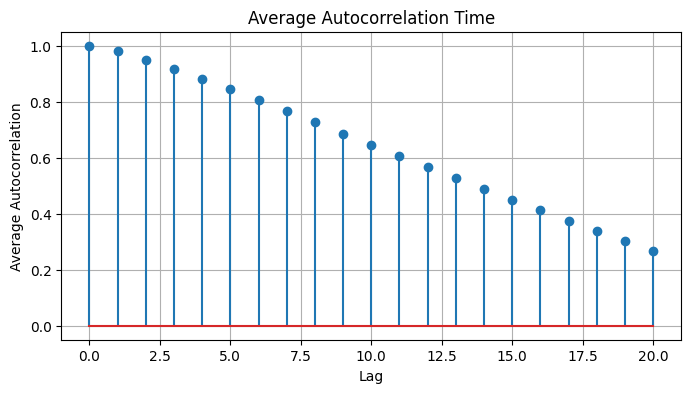

In [14]:
# Example dataset: Replace with your own array data
# Each row represents a separate time series

# Define the maximum lag to consider
max_lag = 20

def autocorrelation(x, lag):
    """
    Calculate the autocorrelation of a 1D array x at a specific lag.
    """
    n = len(x)
    x_mean = np.mean(x)
    c0 = np.sum((x - x_mean) ** 2) / n
    
    return np.sum((x[:n - lag] - x_mean) * (x[lag:] - x_mean)) / (n - lag) / c0

# Calculate autocorrelation for each series and lag
acf_values = np.zeros((all_features.shape[0], max_lag + 1))
for i, series in enumerate(all_features):
    for lag in range(max_lag + 1):
        acf_values[i, lag] = autocorrelation(series, lag)

# Compute the average autocorrelation across all series
avg_acf = np.mean(acf_values, axis=0)

# Plot the average autocorrelation
plt.figure(figsize=(8, 4))
plt.stem(range(max_lag + 1), avg_acf)
plt.xlabel('Lag')
plt.ylabel('Average Autocorrelation')
plt.title('Average Autocorrelation Time')
plt.grid()
plt.show()


In [10]:
data_df = pd.DataFrame()
labels_df = pd.Series()

data_df['id'] = np.repeat(np.arange(all_features.shape[0]),all_features.shape[1])
data_df['time'] = np.tile(np.arange(all_features.shape[1]), all_features.shape[0])
data_df['feature'] = all_features.flatten()
data_df.to_parquet('rawFeatures/data_df.parquet')

labels_df['labels'] = label_arr

data_df

,id,time,feature
0,0,0,13.753024
1,0,1,14.674004
2,0,2,15.638559
3,0,3,16.635180
4,0,4,17.650384
...,...,...,...
23995,239,95,99.589572
23996,239,96,116.361242
23997,239,97,130.567564
23998,239,98,141.191315


In [11]:
# gc.collect()
# Load data once
dask_df = dd.read_parquet('rawFeatures/data_df.parquet')

# Extract features
extracted_features = extract_features(dask_df, column_id="id", column_sort="time",n_jobs=-1, disable_progressbar=False).compute()

# Handle any NaNs
impute(extracted_features)

# Convert labels to a Series (ensure it’s 1D if needed)
labels_series =  pd.Series(np.array(labels_df.to_numpy()[0]))

# Select relevant features
features_filtered = select_features(extracted_features, labels_series, multiclass=True)

# Save to a .npy file with memory-mapping enabled
# np.save('features_extracted_8_sim.npy', features_filtered.to_numpy())
# gc.collect()

In [ ]:
from_columns(features_filtered)["feature"].keys()


dict_keys(['abs_energy', 'absolute_maximum', 'absolute_sum_of_changes', 'agg_autocorrelation', 'agg_linear_trend', 'approximate_entropy', 'ar_coefficient', 'augmented_dickey_fuller', 'autocorrelation', 'binned_entropy', 'c3', 'change_quantiles', 'cid_ce', 'count_above_mean', 'count_below_mean', 'cwt_coefficients', 'energy_ratio_by_chunks', 'fft_aggregated', 'fft_coefficient', 'first_location_of_maximum', 'first_location_of_minimum', 'fourier_entropy', 'friedrich_coefficients', 'index_mass_quantile', 'kurtosis', 'large_standard_deviation', 'last_location_of_maximum', 'last_location_of_minimum', 'lempel_ziv_complexity', 'linear_trend', 'longest_strike_above_mean', 'longest_strike_below_mean', 'max_langevin_fixed_point', 'maximum', 'mean', 'mean_abs_change', 'mean_change', 'mean_n_absolute_max', 'mean_second_derivative_central', 'median', 'number_cwt_peaks', 'number_peaks', 'partial_autocorrelation', 'permutation_entropy', 'quantile', 'ratio_beyond_r_sigma', 'root_mean_square', 'sample_en

In [ ]:
# features_filtered.columns.to_numpy()

np.save("dataExt/tsfresh_feature_names.npy", features_filtered.columns.to_numpy())


(485,)